<a href="https://colab.research.google.com/github/DenisLVA/sigmoidal_data_science/blob/main/Projeto_Airbnb_Tokio_Kant%C3%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Obtenção dos Dados

In [38]:
# importar os pacotes necessarios
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [39]:
# importar o arquivo listings.csv para um DataFrame
df = pd.read_csv("https://data.insideairbnb.com/japan/kant%C5%8D/tokyo/2025-09-29/visualisations/listings.csv")

# **Análise dos Dados**

Tóquio, Kantō, Japão

Dicionário das Variáveis



*   `id` -  Número de id gerado para identificar o imóvel
*   `name` - nome da propriedade anunciada
*   `host_id` - número de id do proprietário (anfitrião) da propriedade
*   `host_name` - Nome do anfitrião
*   `neighbourhood_group` - Esta coluna não contém nenhum valor valido
*   `neighbourhood` - Nome do bairro
*   `Latitude` - Coordenada da latitude da propriedade
*   `Longitude` - Coordenada da longitude da propriedade
*   `room_type` - informa o tipo de quarto que é oferecido
*   `price` - preço para alugar o imóvel
*   `minimum_nights` - quantidade minima de noites para reservar
*   `number_of_reviews` - número de reviews que a propriedade possui
*   `last_review` - data do útimo review
*   `reviwes_per_month` - quantidade de reviews por mês
*   `calculated_host_listings_count` - quantidade de imóveis do mesmo anfitrião
*   `availability_365` -  número de dias de disponibilidade dentro de 365 dias
*   `number_of_review_itm` -  Avaliações de imóveis por anúncio
*   `license` - Esta coluna não contém nenhum valor valido




In [40]:
# Mostrar as 5 primeiras entradas
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,197677,Oshiage Holiday Apartment,964081,Yoshimi & Marek,NaN,Sumida Ku,35.71707,139.82608,Entire home/apt,12600.0,3,190,2025-08-24,1.11,1,183,10,M130003350
1,776070,Kero-kero room 1F,801494,Kei,NaN,Kita Ku,35.73844,139.76917,Private room,10459.0,3,272,2025-05-21,1.74,1,76,14,M130000243
2,905944,4F Spacious Apartment in Shinjuku / Shibuya Tokyo,4847803,Best Stay In Tokyo!,NaN,Shibuya Ku,35.67878,139.67847,Entire home/apt,33671.0,5,281,2025-09-21,1.85,9,305,50,Hotels and Inns Business Act | 渋谷区保健所長 | 31渋健生...
3,1016831,5 mins Shibuya Cat modern sunny Shimokita,5596383,Wakana,NaN,Setagaya Ku,35.65800,139.67134,Private room,24143.0,1,284,2025-09-21,1.87,1,80,16,M130001107
4,1196177,Homestay at Host's House - Senju-Ohashi Station,5686404,Yukiko,NaN,Adachi Ku,35.74363,139.79852,Private room,8795.0,2,150,2025-09-07,1.01,1,253,25,M130007760


#  Q1. Quantos atributos (variáveis) e quantas entradas o nosso conjunto de dados possui? Quais os tipos das variáveis?
Vamos seguir e identificar a quantidade de entradas que nosso conjunto de dados possui e ver os tipos de cada coluna.

In [41]:
# identificar o volume de dados do DataFrame
print("Entradas:\t{}".format(df.shape[0]))
print("Variáveis:\t{}\n".format(df.shape[1]))

# Verificar as 5 primeiras entradas do dataset
print(df.dtypes)


Entradas:	27945
Variáveis:	18

id                                  int64
name                               object
host_id                             int64
host_name                          object
neighbourhood_group               float64
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                             float64
minimum_nights                      int64
number_of_reviews                   int64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
number_of_reviews_ltm               int64
license                            object
dtype: object


## Q2. Qual a porcentagem de valores ausentes no dataset?

 A qualidade de um dataset está diretamente relacionada á quantidade de valores ausentes. É importante entender logo no início se esses valores nulos são signiticativos comparados ao total de entradas.

 * É possível ver que a coluna `neighbourhood_group` possui 100% dos seus valores faltantes


In [42]:
# ordenar em ordem decrescente as variáveis por seus valores ausentes
(df.isnull().sum()/ df.shape[0]).sort_values(ascending=False)

,0
neighbourhood_group,1.000000
reviews_per_month,0.140848
last_review,0.140848
price,0.088209
license,0.000573
host_name,0.000250
name,0.000000
id,0.000000
neighbourhood,0.000000
host_id,0.000000


### Q3. Qual o tipo de distribuição das variáveis?

Para identificar a distribuição das Variáveis, irei plotar o histograma


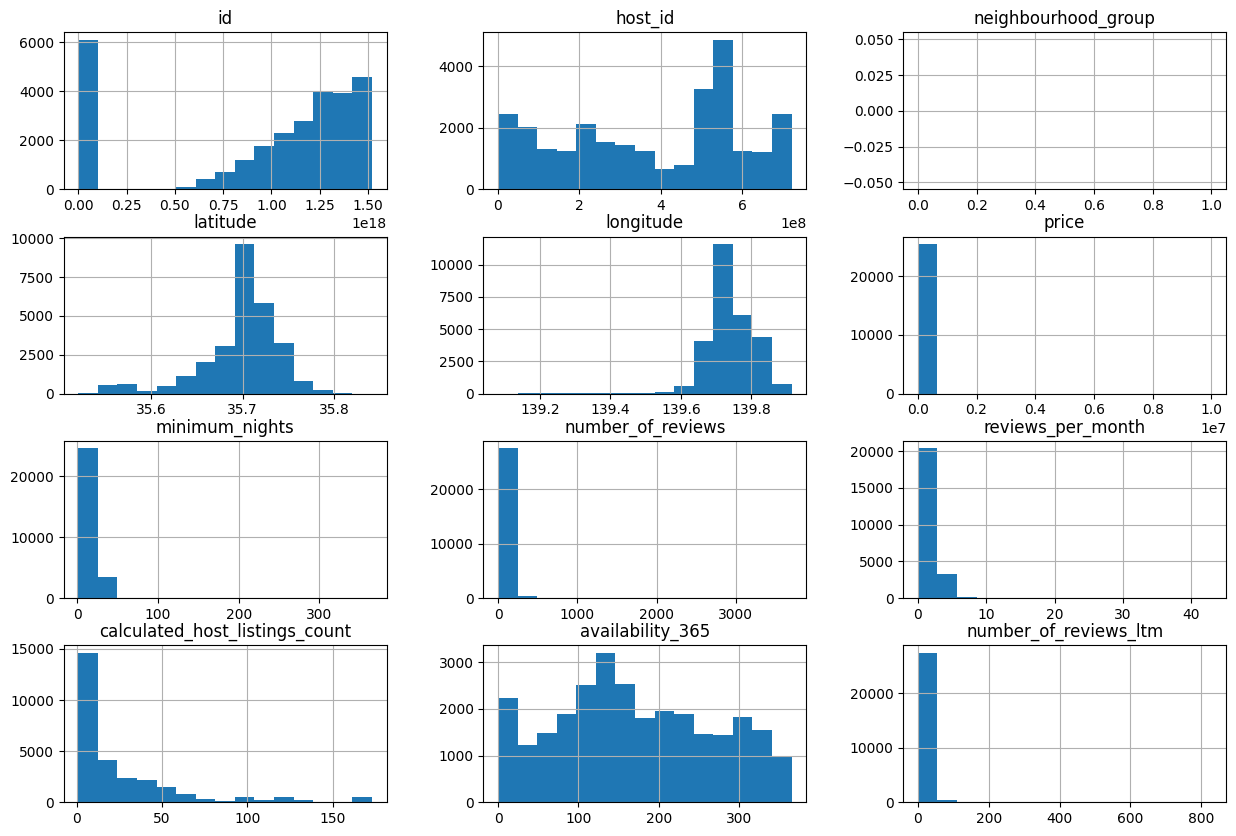

In [43]:
# plotar o histograma das variáveis numéricas
df.hist(bins=15, figsize=(15,10));

#### **Q4. Há *outliers* presentes?**
 Pela distribuição do histograma, é possível verificar indícios da presença de outliers. Olhe por exemplo as variáveis `price` e  `minimum_nights`.
 Os Valores não seguem uma distribuição, e distorcem toda a represenção gráfica. Para confirmar, há duas maneiras rápidas que auxiliam a detecção de outliers. São elas:

 * Resumo estatístico por meio do método  `describe()`
 * Plotar `boxplots` para a variável.

In [44]:
# Ver o resumo estatístico das variáveis numéricas
df[['price','minimum_nights', 'number_of_reviews', 'calculated_host_listings_count', 'availability_365']].describe()


,price,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365
count,2.548000e+04,27945.000000,27945.000000,27945.000000,27945.000000
mean,2.478188e+04,5.317373,35.965361,25.348756,170.259939
std,7.786575e+04,10.724967,66.325593,34.249495,98.205385
min,1.500000e+03,1.000000,0.000000,1.000000,0.000000
25%,1.120150e+04,1.000000,2.000000,4.000000,99.000000
50%,1.620000e+04,2.000000,16.000000,11.000000,159.000000
75%,2.504500e+04,2.000000,42.000000,34.000000,247.000000
max,9.999998e+06,365.000000,3705.000000,173.000000,365.000000


Olhando o resumo estatístico acima, podemos confirmar algumas hipóteses como:
* A variável `price` possui 75% do valor abaixo de 25045, sendo que seu valor máximo é de 9999998.
* A quantidade minima de noite `minimum_nights` está enquadrada nos 365 dias do ano. Sendo que a maior parte de seus imóveis são alugados por 2 noites.  
* Mediana 16.200 iene
* 75% dos imóveis custam até 25.045 iene
* Preço máximo 9.999.998 iene
* A média 24.781 iene

Boxplot para minimum_nights


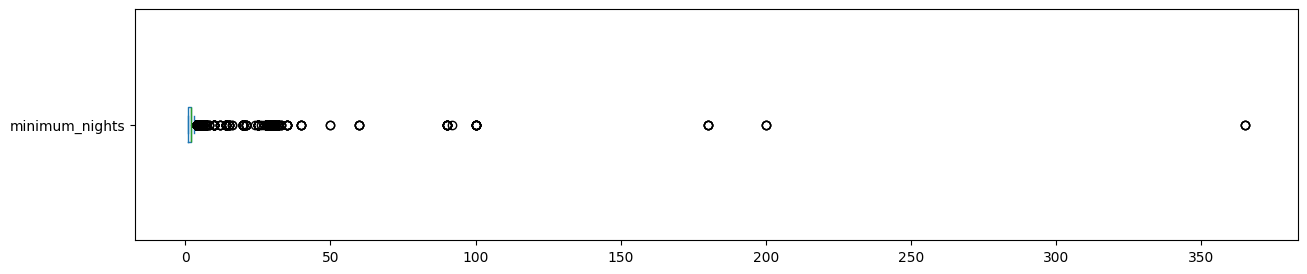

minimum_nigts: valores acima de 30:
197 entradas
0.7050%


In [45]:
# minimum_nights
df.minimum_nights.plot(kind='box', vert=False, figsize=(15,3))
plt.show()


# ver quantidade de valores acima de 30 dias para minimum_nigts
print("minimum_nigts: valores acima de 30:")
print("{} entradas".format(len(df[df.minimum_nights > 30])))
print("{:.4f}%".format((len(df[df.minimum_nights > 30]) / df.shape[0])*100))

Boxplot para price

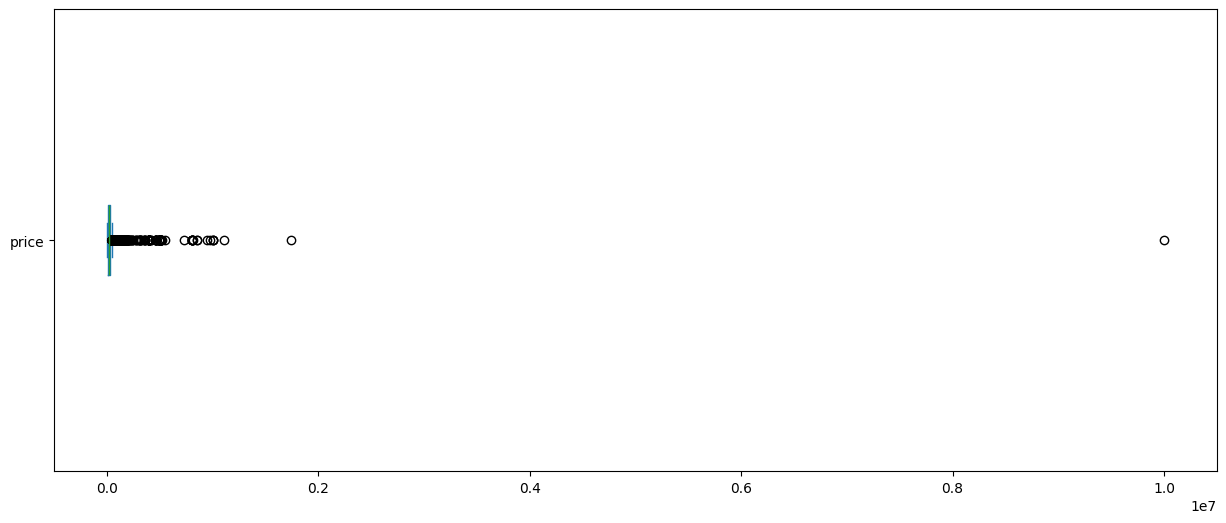


price: valores acima de 2500
25441 entradas
91.0395%


In [46]:
# price
df.price.plot(kind='box', vert=False, figsize=(15,6),)
plt.show()

# ver quantidade de valores acima de 2500 para price
print("\nprice: valores acima de 2500")
print("{} entradas".format(len(df[df.price > 2500])))
print("{:.4f}%".format((len(df[df.price > 2500]) / df.shape[0])*100))

# df.price.plot(kind='box', vert=False, xlim=(0,1300), figsize=(15,6));

Histogramas sem outliers
Já que identificamos outliers nas variáveis `price` e `minimum_nights`, vamos agora limpar o DataFrame delas e plotar novamente o histograma.

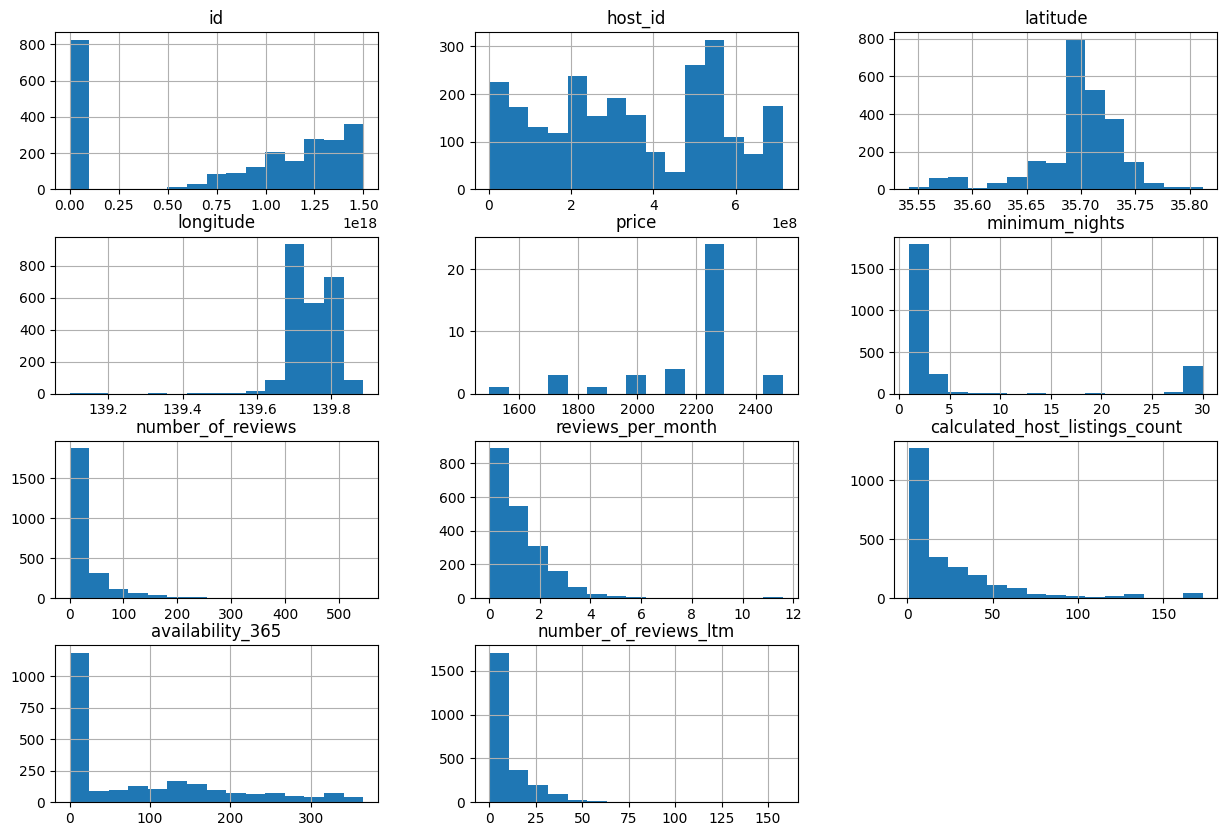

In [47]:
# remover os *outliers* em um novo DataFrame
df_clean = df.copy()
df_clean.drop(df_clean[df_clean.price > 2500].index, axis=0, inplace=True)
df_clean.drop(df_clean[df_clean.minimum_nights > 30].index, axis=0, inplace=True)

# remover `neighbourhood_group`, pois está vazio
df_clean.drop('neighbourhood_group', axis=1, inplace=True)

# plotar o histograma para as  variáveis numéricas
df_clean.hist(bins=15, figsize=(15,10));

##### Q5. Qual a correlação existente entre as variáveis?
Correlação significa que existe uma relação entre duas coisas. No nosso contexto, estamos buscando relação ou semelhança entre duas variáveis.

Essa relação pode ser medida, e é função do coeficiente de correlação estabelecer qual a intensidade dela. Para identificar as correlações existentes entre as variáveis de interesse, vou:

Criar uma matriz de correlação
Gerar um heatmap a partir dessa matriz, usando a biblioteca `seaborn`

In [48]:
# criar uma matriz de correlação
corr = df_clean[['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month',
    'calculated_host_listings_count', 'availability_365']].corr()
display(corr)

,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
price,1.000000,-0.648346,-0.021479,0.205139,0.453256,-0.115427
minimum_nights,-0.648346,1.000000,-0.206426,-0.174635,0.255493,0.044270
number_of_reviews,-0.021479,-0.206426,1.000000,0.488823,-0.123451,-0.030869
reviews_per_month,0.205139,-0.174635,0.488823,1.000000,-0.013056,0.057248
calculated_host_listings_count,0.453256,0.255493,-0.123451,-0.013056,1.000000,-0.040407
availability_365,-0.115427,0.044270,-0.030869,0.057248,-0.040407,1.000000


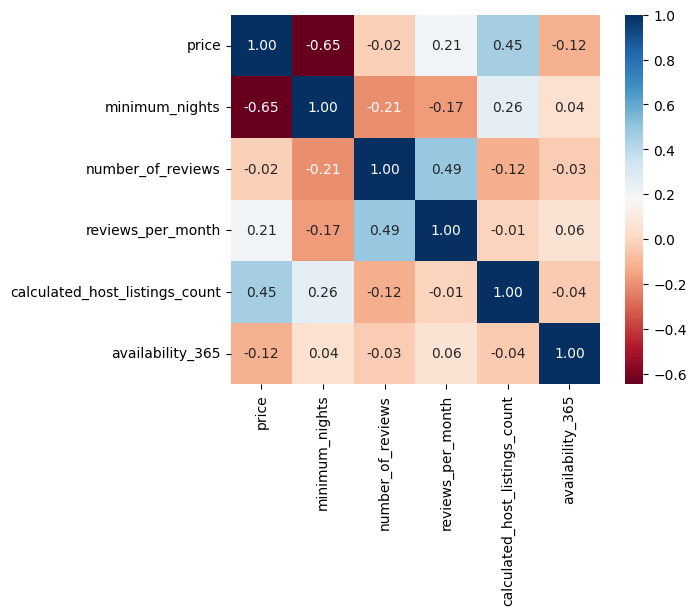

In [49]:
sns.heatmap(corr, cmap='RdBu', fmt='.2f', square=True, linecolor='white', annot=True);

###### Q6. Qual o tipo de imóvel mais alugado no Airbnb?
A coluna da variável `room_type` indica o tipo de locação que está anunciada no Airbnb. Se você já alugou no site, sabe que existem opções de apartamentos/casas inteiras, apenas o aluguel de um quarto ou mesmo dividir o quarto com outras pessoas.

Vamos contar a quantidade de ocorrências de cada tipo de aluguel, usando o método `value_counts()`.

In [50]:
# mostrar a quantidade de cada tipo de imóvel disponível
df_clean.room_type.value_counts()
print(df_clean.room_type.value_counts())

room_type
Entire home/apt    1615
Private room        713
Shared room          62
Hotel room           49
Name: count, dtype: int64


In [51]:
# mostrar a quantidade de cada tipo de imóvel disponível
df_clean.room_type.value_counts() / df_clean.shape[0]
print(df_clean.room_type.value_counts() / df_clean.shape[0])

room_type
Entire home/apt    0.662157
Private room       0.292333
Shared room        0.025420
Hotel room         0.020090
Name: count, dtype: float64


In [52]:
# mostrar a porcentagem de cada tipo de imóvel disponível
df_clean.room_type.value_counts() / df_clean.shape[0]
print(df_clean.room_type.value_counts() / df_clean.shape[0])

room_type
Entire home/apt    0.662157
Private room       0.292333
Shared room        0.025420
Hotel room         0.020090
Name: count, dtype: float64


###### Q6. Qual a localidade mais cara de Tokio?

Uma maneira de se verificar uma variável em função da outra é usadando`groupb()`. No caso, queremos comparar os bairros (neighbournhoods) a partir do preço de locação.

In [53]:
print((df_clean.groupby(['neighbourhood'])['price'].mean().sort_values(ascending=False))[:7])


neighbourhood
Kita Ku          2472.000000
Taito Ku         2253.000000
Sumida Ku        2229.230769
Katsushika Ku    2129.000000
Ota Ku           2015.000000
Toshima Ku       1700.000000
Hachioji Shi     1500.000000
Name: price, dtype: float64


Acima vemos a média de bairros que são mais caros!

In [54]:
# ver quantidade de imóveis no Sumida Ku
print(df_clean[df_clean.neighbourhood == "Sumida Ku"].shape)

# ver as entradas do complexo do Sumida Ku
df_clean[df_clean.neighbourhood == "Sumida Ku"]

(382, 17)


,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
216,9175436,Japanese-style guest house near Asakusa & Skytree,37087932,Konoha House,Sumida Ku,35.709440,139.801910,Entire home/apt,NaN,1,258,2023-04-07,2.16,2,0,0,Hotels and Inns Business Act | 墨田区保健所 | 4墨福衛生環...
306,11212330,Close to Asakusa / Skytree,37456117,Haru,Sumida Ku,35.724760,139.823390,Entire home/apt,NaN,3,145,2025-08-24,1.25,16,3,16,Hotels and Inns Business Act | 東京都墨田区保健所 | 30墨...
332,11978095,"R303--Skytree 8mins,Airport directly,Asakusa 3...",50705816,Qiong,Sumida Ku,35.711940,139.820470,Private room,NaN,1,283,2025-09-13,2.48,11,0,38,Hotels and Inns Business Act | 墨田区保健所 | 5墨福衛生環...
540,15805213,"102-Skytree 8min,Asakusa/Ueno/Narita/Haneda di...",50705816,Qiong,Sumida Ku,35.710130,139.818470,Private room,NaN,1,157,2025-09-14,1.45,11,0,47,Hotels and Inns Business Act | 墨田区保健所 | 5墨福衛生環...
579,16115606,【OpenAirBath】GrapeRowHouse 2F｜7min walk to sta...,104113360,敏雄,Sumida Ku,35.716032,139.823750,Private room,NaN,2,544,2025-09-24,5.08,3,112,57,Hotels and Inns Business Act | 墨田区保健所 | 28墨福衛生...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26629,1485259017537700033,nestay apartment tokyo skytree 6A,356490069,Lifeng,Sumida Ku,35.700250,139.812860,Entire home/apt,NaN,1,1,2025-09-04,1.00,54,180,1,M130052934
26681,1485532671113907989,錦糸町駅徒歩4分-1F/スカイツリー2分､浅草5分、渋谷･新宿･秋葉原に直通/空港から便利/...,517292500,Jiro,Sumida Ku,35.699145,139.812798,Entire home/apt,NaN,1,1,2025-09-15,1.00,10,125,1,Hotels and Inns Business Act | 墨田区保健所 | 7墨衛生環第８７号
26709,1486237994690852768,錦糸町駅徒歩4分-3F/スカイツリー2分､浅草5分、渋谷･新宿･秋葉原に直通/空港から便利/...,517292500,Jiro,Sumida Ku,35.699145,139.812798,Entire home/apt,NaN,2,0,NaN,NaN,10,0,0,Hotels and Inns Business Act | 墨田区保健所 | ７墨衛生環第８７号
27234,1497837533747777868,浅草203;浅草徒歩8分;スカイツリー徒歩圏内;最大4名,189502014,雲逸,Sumida Ku,35.703670,139.799757,Entire home/apt,NaN,1,1,2025-09-15,1.00,40,42,1,M130055034


Como são fornecidas as Latitudes e Longitudes para os imóveis, é possível plotar cada ponto. Para isso, considera-se `x=longitude` e `y=latitude`.

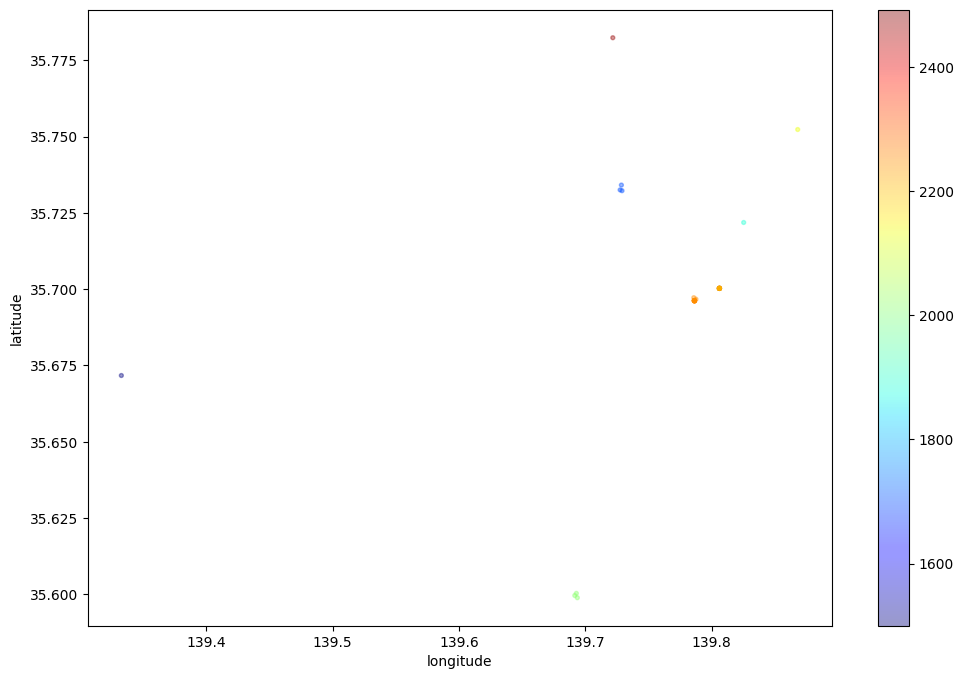

In [57]:
# Plotar os Imóveis pela latitude-longitude
df_clean.plot(kind="scatter", x='longitude', y='latitude', alpha=0.4, c=df_clean['price'], s=8,
              cmap=plt.get_cmap('jet'), figsize=(12,8));

# Conclusão

Na análise dos dados do Airbnb de Tóquio, na região de Kantō, foram identificados outliers de preços que geraram uma forte concentração de valores acima de 45.810 ienes por diária. Esses outliers impactaram significativamente a média e a distribuição dos dados. Além disso, a elevada concentração de anúncios em determinadas localidades contribuiu para a supervalorização dos preços de aluguel, influenciando diretamente o comportamento do mercado nessas regiões.